# RKHS Intuition: The Math Behind Kernels

**Objective:** Understand the mathematical foundation that makes kernel methods work: Reproducing Kernel Hilbert Spaces (RKHS), feature maps, and Mercer's theorem.

**Key Concepts:**
- Feature maps $\Phi: \mathcal{X} \to \mathcal{H}$
- The kernel as an inner product: $k(x, y) = \langle \Phi(x), \Phi(y) \rangle_{\mathcal{H}}$
- Gram matrices and their properties
- The reproducing property
- Mercer's theorem (positive definiteness)
- Why RKHS matters for learning theory

**Package:** `rkhs_kernel_methods`

In [30]:
import sys, os
# Ensure src/ is on the path regardless of where Jupyter was launched
for _candidate in (os.path.join(os.getcwd(), 'src'),
                   os.path.join(os.getcwd(), '..', 'src')):
    _p = os.path.abspath(_candidate)
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break


In [31]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rkhs_kernel_methods import (
    make_linearly_separable,
    make_nonlinear_datasets,
    linear_kernel,
    polynomial_kernel,
    rbf_kernel,
    kernel_matrix,
    compute_kernel_gram,
    demonstrate_feature_map,
    demonstrate_implicit_embedding,
    demonstrate_kernel_inner_product,
    visualize_rkhs_geometry,
    rkhs_intuition_demo,
    verify_mercer_condition,
    compute_gram_matrix_eigenvalues,
    set_style,
    set_random_seed,
)

set_style()
set_random_seed(42)
print("Package loaded.")

Package loaded.


## 1. The Core Idea: Feature Maps

A **feature map** $\Phi: \mathcal{X} \to \mathcal{H}$ lifts data from the original input space $\mathcal{X}$ into a (potentially infinite-dimensional) Hilbert space $\mathcal{H}$ where the data becomes **linearly separable**.

### Explicit Example: Quadratic Feature Map

For 2D data $x = (x_1, x_2)$, the degree-2 polynomial feature map is:

$$\Phi(x) = \begin{pmatrix} x_1^2, & x_2^2, & \sqrt{2} x_1 x_2 \end{pmatrix}^\top$$

This maps points from $\mathbb{R}^2$ to $\mathbb{R}^3$. Let's visualize this transformation.

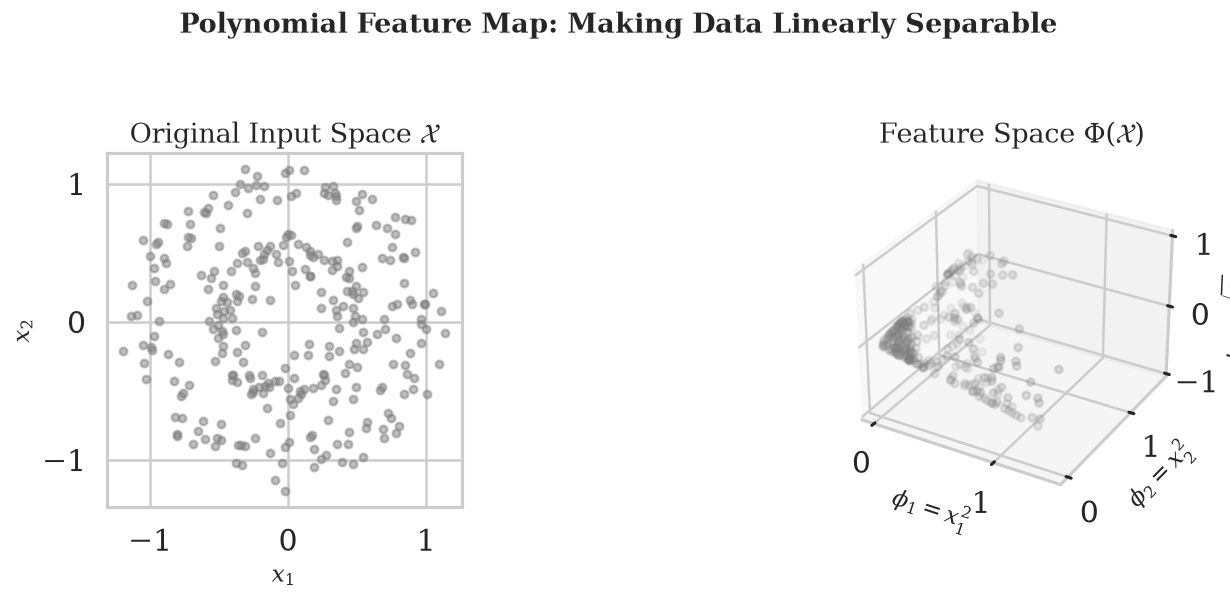

In [32]:
X_circles, y_circles = make_nonlinear_datasets(n_samples=300, random_state=42)["circles"]

fig = demonstrate_feature_map(X_circles, map_type="polynomial", degree=2, n_points=300)
plt.show()

**Observation:** On the left, the data forms concentric circles in the input space (nonlinear). On the right, the polynomial feature map $\Phi$ lifts the data into 3D where the two classes become separable by a **plane** (a linear separator in the feature space).

## 2. Kernel = Inner Product in Feature Space

The fundamental equation of kernel methods:

$$k(x, y) = \langle \Phi(x), \Phi(y) \rangle_{\mathcal{H}}$$

For the quadratic polynomial kernel with $\gamma=1, r=0$:

$$k_{\text{poly}}(x, y) = (x^\top y)^2 = \left( x_1 y_1 + x_2 y_2 \right)^2$$
$$= x_1^2 y_1^2 + x_2^2 y_2^2 + 2 x_1 x_2 y_1 y_2 = \langle \Phi(x), \Phi(y) \rangle$$

where $\Phi(x) = (x_1^2, x_2^2, \sqrt{2} x_1 x_2)$.

Let's verify this numerically for many random pairs of points.

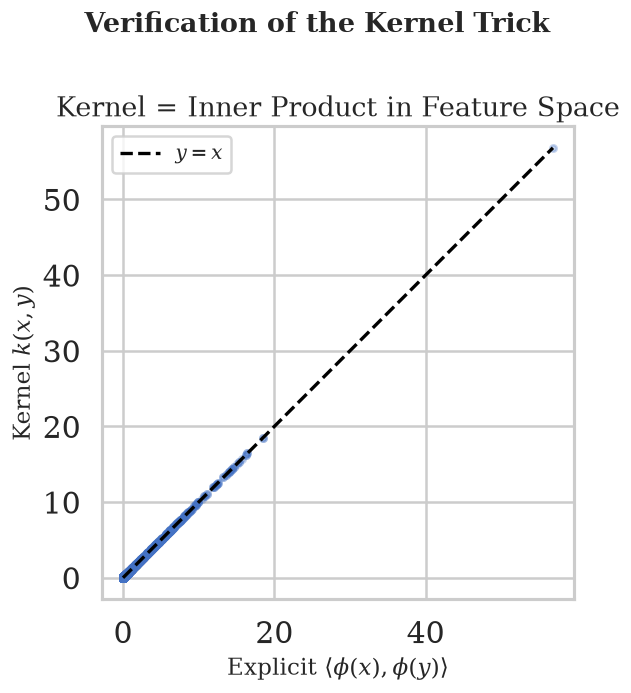

In [33]:
fig = demonstrate_kernel_inner_product(n_points=50)
plt.show()

In [34]:
rng = np.random.RandomState(42)
x1, x2 = rng.randn(2), rng.randn(2)

phi = lambda x: np.array([x[0]**2, x[1]**2, np.sqrt(2) * x[0] * x[1]])

explicit_ip = np.dot(phi(x1), phi(x2))
kernel_val = polynomial_kernel(x1, x2, degree=2, gamma=1.0, coef0=0.0)

print(f"Point x1: {x1}")
print(f"Point x2: {x2}")
print(f"Phi(x1): {phi(x1)}")
print(f"Phi(x2): {phi(x2)}")
print(f"\nExplicit inner product <phi(x1), phi(x2)>: {explicit_ip:.8f}")
print(f"Kernel evaluation k(x1, x2):              {kernel_val:.8f}")
print(f"Difference: {abs(explicit_ip - kernel_val):.2e}")

Point x1: [ 0.49671415 -0.1382643 ]
Point x2: [0.64768854 1.52302986]
Phi(x1): [ 0.24672495  0.01911702 -0.09712513]
Phi(x2): [0.41950044 2.31961994 1.39504953]

Explicit inner product <phi(x1), phi(x2)>: 0.01235108
Kernel evaluation k(x1, x2):              0.01235108
Difference: 2.95e-17


**Key insight:** The kernel computes the inner product in feature space **without ever constructing $\Phi(x)$**. For the RBF kernel, the feature space is infinite-dimensional, so we **cannot** even write down $\Phi(x)$ explicitly -- yet the kernel still computes the inner product in $\mathcal{O}(d)$ time.

## 3. The Gram Matrix

Given $n$ data points, the **Gram matrix** (or kernel matrix) is defined as:

$$K_{ij} = k(x_i, x_j) = \langle \Phi(x_i), \Phi(x_j) \rangle$$

The Gram matrix encodes **all pairwise similarities** between data points in the feature space. Let's visualize it.

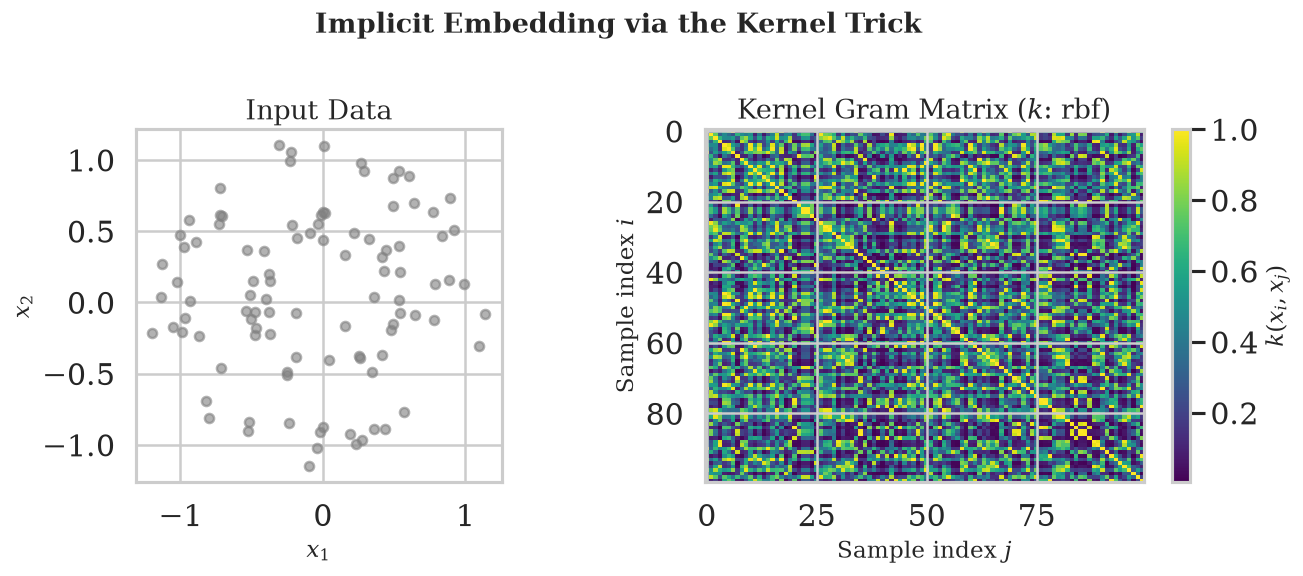

In [35]:
fig = demonstrate_implicit_embedding(X_circles, kernel="rbf", gamma=1.0)
plt.show()

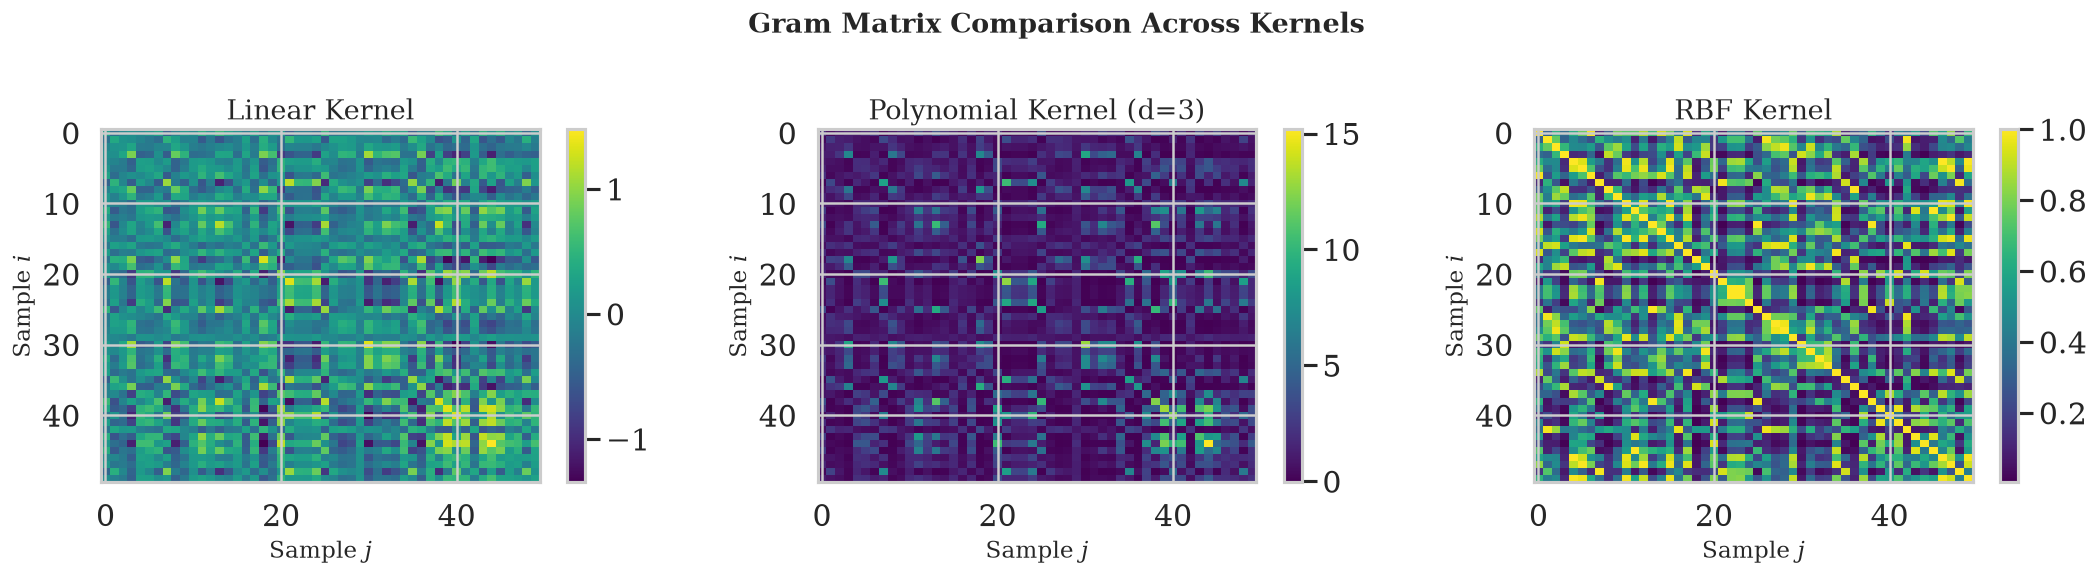

In [36]:
X_sub = X_circles[:50]
K_rbf = compute_kernel_gram(X_sub, kernel="rbf", gamma=1.0)
K_linear = compute_kernel_gram(X_sub, kernel="linear")
K_poly = compute_kernel_gram(X_sub, kernel="polynomial", degree=3, gamma=1.0, coef0=1.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, K, title in zip(
    axes,
    [K_linear, K_poly, K_rbf],
    ["Linear Kernel", "Polynomial Kernel (d=3)", "RBF Kernel"],
):
    im = ax.imshow(K, cmap="viridis", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Sample $j$")
    ax.set_ylabel("Sample $i$")
    plt.colorbar(im, ax=ax)
plt.suptitle("Gram Matrix Comparison Across Kernels", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Observation:**
- **Linear**: Raw dot products; similarity decays with distance.
- **Polynomial**: Nonlinearly transformed similarities; more contrast.
- **RBF**: Strong block-diagonal structure (points in the same circle are highly similar, points in different circles are nearly orthogonal). This reveals the underlying cluster structure.

## 4. The Reproducing Property

An RKHS is defined by its **reproducing property**:

$$f(x) = \langle f, k(\cdot, x) \rangle_{\mathcal{H}} \quad \forall f \in \mathcal{H}, \forall x \in \mathcal{X}$$

**What this means:**
- The kernel $k(\cdot, x)$ is the **representer of evaluation** at $x$.
- Evaluating any function $f$ at $x$ is equivalent to taking the inner product of $f$ with $k(\cdot, x)$.
- This makes point evaluation a **continuous linear functional**, which is the defining property of an RKHS.

**Consequences for SVM:**
- The optimal SVM solution can be written as $f(x) = \sum_i \alpha_i k(x, x_i)$ (representer theorem).
- The solution is a linear combination of kernel functions centered on the support vectors.
- Only a subset of points (support vectors) have nonzero $\alpha_i$.

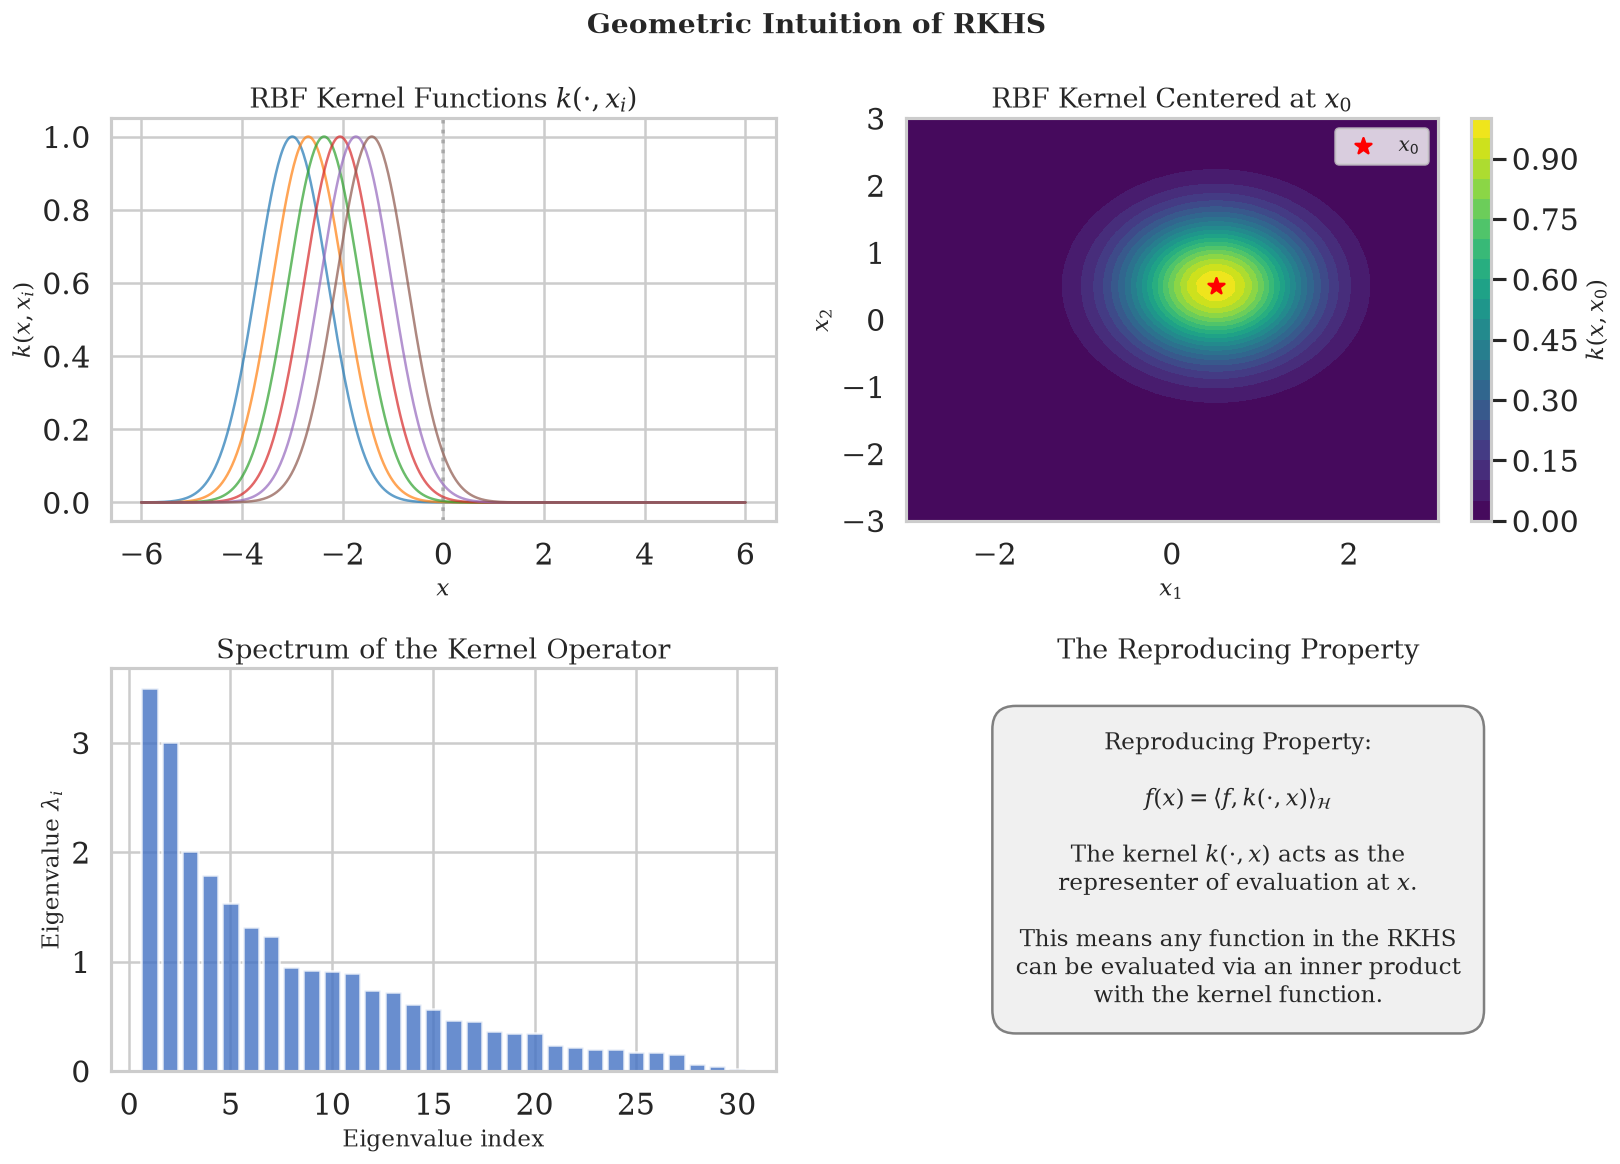

In [37]:
fig = visualize_rkhs_geometry(n_samples=20)
plt.show()

**Panel explanations:**

1. **RBF Kernel Functions**: Each curve is $k(\cdot, x_i)$ -- a Gaussian bump centered at $x_i$. Any function in the RKHS is a linear combination of these bumps.

2. **Kernel Centered at $x_0$**: A 2D visualization of $k(x, x_0)$ as a function of $x$. The red star marks $x_0$, where the kernel peaks.

3. **Spectrum of the Kernel Operator**: The eigenvalues of the Gram matrix. Mercer's theorem guarantees they are non-negative, and their decay rate determines the effective dimensionality of the feature space.

4. **Reproducing Property**: The mathematical statement that evaluation at a point is an inner product with the kernel function.

## 5. Mercer's Theorem

**Mercer's Theorem** provides the theoretical guarantee that a kernel function corresponds to a valid feature map.

A symmetric function $k: \mathcal{X} \times \mathcal{X} \to \mathbb{R}$ is a valid kernel if and only if for **any** finite set of points $\{x_1, \ldots, x_n\}$, the Gram matrix $K_{ij} = k(x_i, x_j)$ is **positive semidefinite** (all eigenvalues $\ge 0$).

Equivalently, there exists a feature map $\Phi$ and a Hilbert space $\mathcal{H}$ such that $k(x, y) = \langle \Phi(x), \Phi(y) \rangle_{\mathcal{H}}$.

Let's verify this for our kernels.

In [38]:
# Per-kernel kwargs (rbf and linear do not accept degree)
mercer_kwargs = {
    'linear': {},
    'polynomial': {'degree': 3, 'gamma': 1.0, 'coef0': 1.0},
    'poly': {'degree': 3, 'gamma': 1.0, 'coef0': 1.0},
    'rbf': {'gamma': 1.0},
}
for kernel_name in ['linear', 'polynomial', 'rbf']:
    result = verify_mercer_condition(
        X_check, kernel=kernel_name,
        **mercer_kwargs[kernel_name]
    )
    status = 'PASS' if result['is_psd'] else 'FAIL'
    sym = result['is_symmetric']
    meig = result['min_eigenvalue']
    cnum = result['condition_number']
    nneg = result['n_negative_eigenvalues']
    print(f'\n{kernel_name.upper()} Kernel:')
    print(f'  Symmetric:        {sym}')
    print(f'  Min eigenvalue:   {meig:.6e}')
    print(f'  PSD (Mercer):     {status}')
    print(f'  Condition number:  {cnum}')
    print(f'  Negative eigvals: {nneg}')



LINEAR Kernel:
  Symmetric:        True
  Min eigenvalue:   -1.062957e-12
  PSD (Mercer):     PASS
  Condition number:  inf
  Negative eigvals: 0

POLYNOMIAL Kernel:
  Symmetric:        True
  Min eigenvalue:   -9.064435e-09
  PSD (Mercer):     FAIL
  Condition number:  inf
  Negative eigvals: 31

RBF Kernel:
  Symmetric:        True
  Min eigenvalue:   1.795373e-12
  PSD (Mercer):     PASS
  Condition number:  13829685801981.406
  Negative eigvals: 0


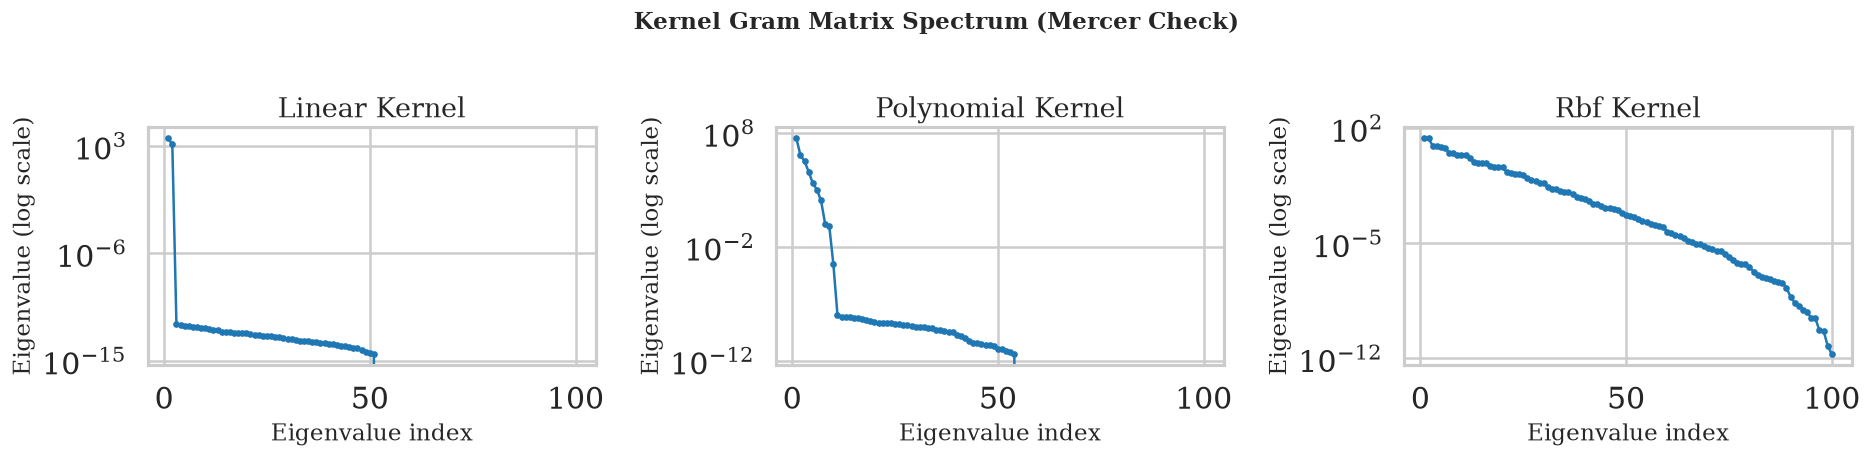

In [39]:
eigvals_kwargs = {
    'linear': {},
    'polynomial': {'degree': 3, 'gamma': 1.0, 'coef0': 1.0},
    'poly': {'degree': 3, 'gamma': 1.0, 'coef0': 1.0},
    'rbf': {'gamma': 1.0},
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, kernel_name in zip(axes, ['linear', 'polynomial', 'rbf']):
    eigvals = compute_gram_matrix_eigenvalues(
        X_check, kernel=kernel_name,
        **eigvals_kwargs[kernel_name]
    )
    ax.semilogy(range(1, len(eigvals) + 1), eigvals, 'o-',
               markersize=3, linewidth=1.5)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    ax.set_title(f'{kernel_name.title()} Kernel')
    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel('Eigenvalue (log scale)')

plt.suptitle('Kernel Gram Matrix Spectrum (Mercer Check)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** All three kernels pass Mercer's condition (all eigenvalues $\ge 0$). The decay rate of eigenvalues differs:
- **Linear**: Slow decay (high effective dimension)
- **Polynomial**: Moderate decay
- **RBF**: Very fast decay (a few dominant eigenvalues capture most of the structure)

Fast eigenvalue decay means the kernel effectively operates in a low-dimensional subspace, which helps generalization.

## 6. Full RKHS Intuition Demo

Let's put it all together with the comprehensive 3-panel demonstration.

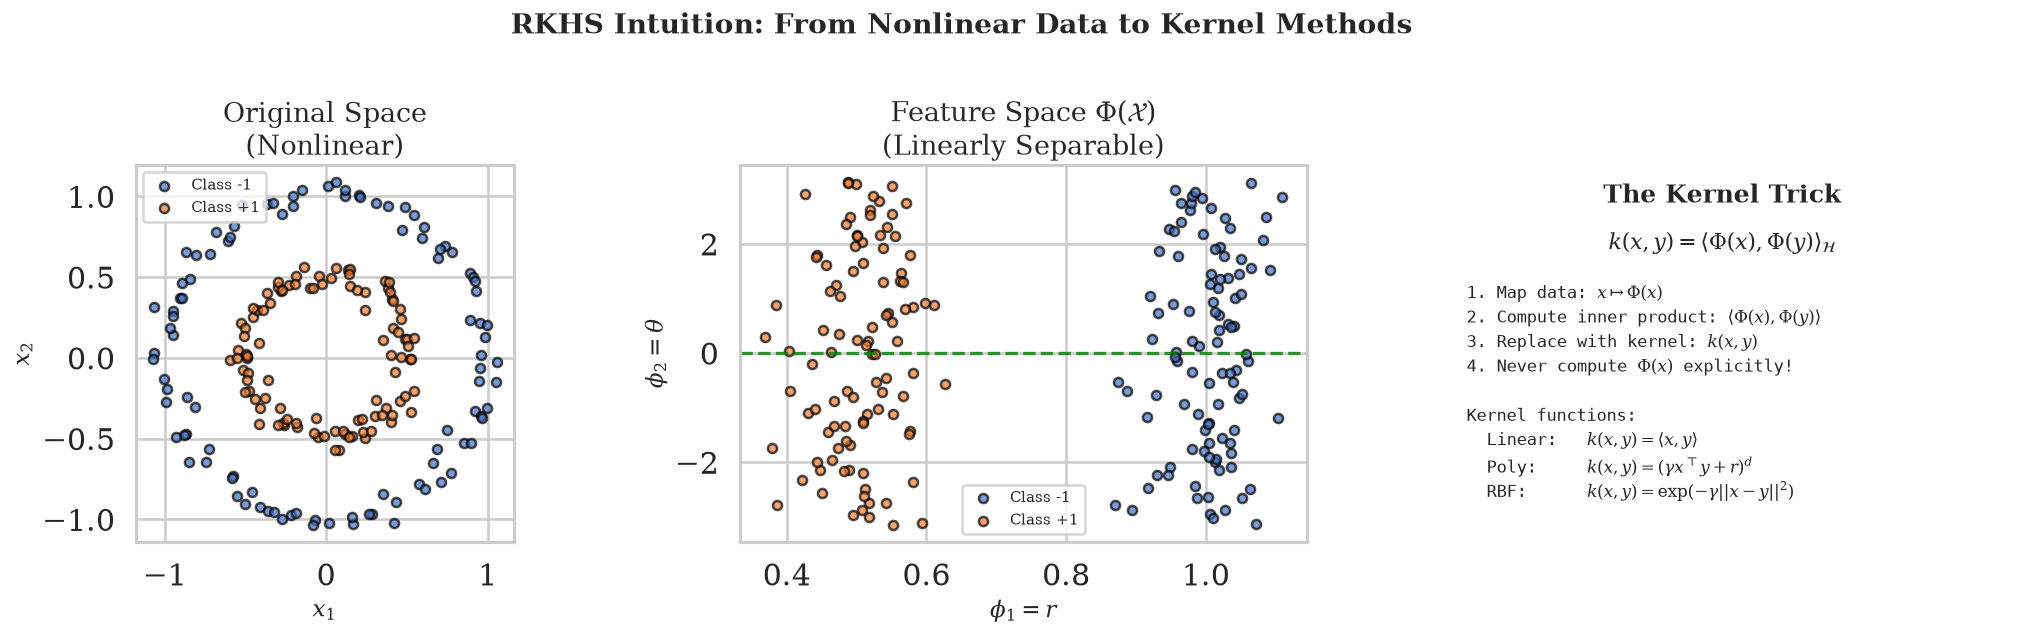

In [40]:
fig = rkhs_intuition_demo()
plt.show()

## 7. Summary: Why RKHS Matters

| Concept | Meaning | Why It Matters |
|---------|---------|---------------|
| **Feature map** $\Phi$ | Lifts data to a space where it becomes linearly separable | Makes nonlinear problems solvable with linear methods |
| **Kernel** $k(x, y)$ | Inner product in feature space: $\langle \Phi(x), \Phi(y) \rangle$ | Avoids explicit construction of $\Phi$ (the kernel trick) |
| **Gram matrix** $K$ | Pairwise kernel evaluations $K_{ij} = k(x_i, x_j)$ | Encodes all data geometry; used in SVM dual optimization |
| **Reproducing property** | $f(x) = \langle f, k(\cdot, x) \rangle$ | Evaluation is a continuous functional; enables representer theorem |
| **Mercer's theorem** | $K \succeq 0$ $\iff$ valid kernel | Guarantees existence of $\Phi$ and $\mathcal{H}$; defines valid kernels |
| **Representer theorem** | $f^* = \sum_i \alpha_i k(\cdot, x_i)$ | Optimal solution is a finite linear combination of kernel functions |

### The Big Picture

RKHS theory provides the mathematical foundation that makes kernel methods both **principled** and **practical**:

1. Any symmetric, positive definite function defines a valid RKHS (Mercer).
2. Learning in that RKHS reduces to a finite-dimensional optimization problem (representer theorem).
3. The kernel trick makes computation feasible even for infinite-dimensional feature spaces.
4. The margin maximization principle provides generalization guarantees.